In [1]:
import numpy as np
import pandas as pd
from tqdm import trange
import matplotlib.pyplot as plt
import math
import scipy.stats as stats
import corner
import emcee
import scipy
import random
import sys
import time
import neuralop
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
# # import  settings

sys.path.append('../..')
import plot_settings
plot_settings.apply()


import importlib
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

import exp_pybamm
importlib.reload(exp_pybamm)

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'exp_pybamm' from '/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/NO/NO_code_examples/../../exp_pybamm.py'>

Example from [DeepXDE](https://deepxde.readthedocs.io/en/latest/demos/operator/poisson.1d.pideeponet.html)

We will learn the solution operator $$G:f\rightarrow u$$ for the one-dimensional Poisson problem $$\nabla^2 u(x)=f(x),\quad x\in[0,1]$$
with zero Dirichlet boundary conditions $u(0)=u(1)=0$.
The source term, $ƒ$, is supposed to be an arbitrary continuous function.


Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Compiling model...
'compile' took 0.000225 s

Training model...

Step      Train loss              Test loss               Test metric
0         [3.49e-01, 1.63e-01]    [3.49e-01, 1.63e-01]    []  
1000      [1.14e-05, 2.02e-06]    [1.14e-05, 2.02e-06]    []  

Best model at step 1000:
  train loss: 1.34e-05
  test loss: 1.34e-05
  test metric: []

'train' took 292.929062 s



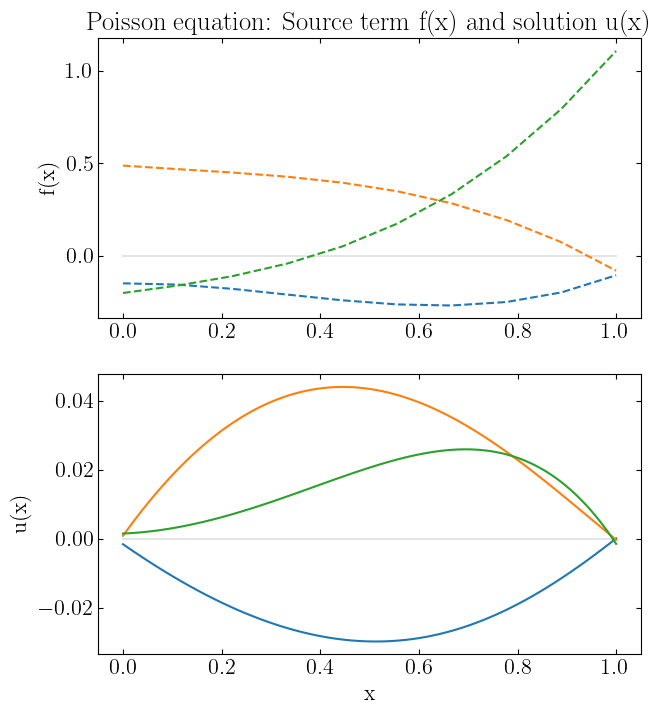

In [ ]:
"""Backend supported: tensorflow.compat.v1, tensorflow, pytorch, paddle"""
import os
os.environ["DDE_BACKEND"] = "pytorch"

import deepxde as dde
from deepxde.backend import torch

import matplotlib.pyplot as plt
import numpy as np


# Poisson equation: -u_xx = f
def equation(x, y, f):
    dy_xx = dde.grad.hessian(y, x)
    return -dy_xx - f


# Domain is interval [0, 1]
geom = dde.geometry.Interval(0, 1)


# Zero Dirichlet BC
def u_boundary(_):
    return 0


def boundary(_, on_boundary):
    return on_boundary


bc = dde.icbc.DirichletBC(geom, u_boundary, boundary)

# Define PDE
pde = dde.data.PDE(geom, equation, bc, num_domain=100, num_boundary=2)

# Function space for f(x) are polynomials
degree = 3
space = dde.data.PowerSeries(N=degree + 1)

# Choose evaluation points
num_eval_points = 10
evaluation_points = geom.uniform_points(num_eval_points, boundary=True)

# Define PDE operator
pde_op = dde.data.PDEOperatorCartesianProd(
    pde,
    space,
    evaluation_points,
    num_function=100,
)

# Setup DeepONet
dim_x = 1
p = 32
net = dde.nn.DeepONetCartesianProd(
    [num_eval_points, 32, p],
    [dim_x, 32, p],
    activation="tanh",
    kernel_initializer="Glorot normal",
)

# Define and train model
model = dde.Model(pde_op, net)
dde.optimizers.set_LBFGS_options(maxiter=1000)
model.compile("L-BFGS")
model.train()


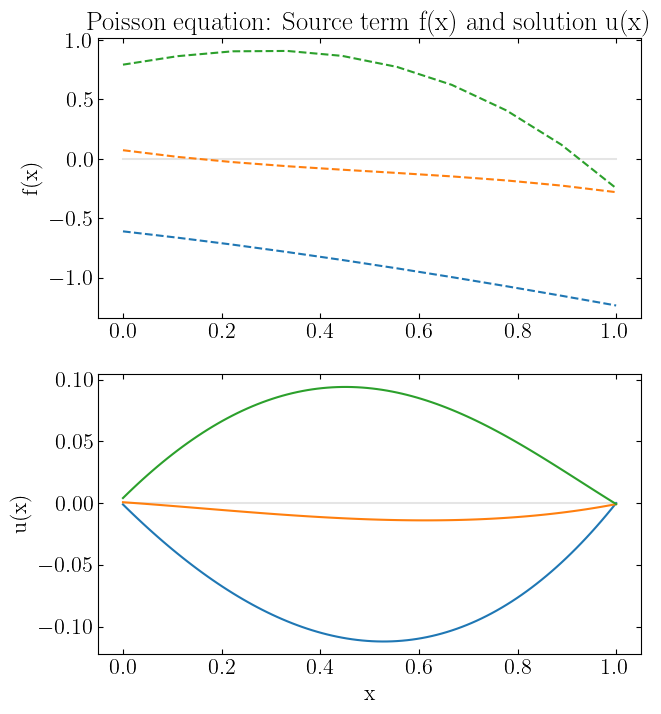

In [28]:

# Plot realisations of f(x)
n = 3
features = space.random(n)
fx = space.eval_batch(features, evaluation_points)

x = geom.uniform_points(100, boundary=True)
y = model.predict((fx, x))

# Setup figure
fig = plt.figure(figsize=(7, 8))
plt.subplot(2, 1, 1)
plt.title("Poisson equation: Source term f(x) and solution u(x)")
plt.ylabel("f(x)")
z = np.zeros_like(x)
plt.plot(x, z, "k-", alpha=0.1)

# Plot source term f(x)
for i in range(n):
    plt.plot(evaluation_points, fx[i], "--")

# Plot solution u(x)
plt.subplot(2, 1, 2)
plt.ylabel("u(x)")
plt.plot(x, z, "k-", alpha=0.1)
for i in range(n):
    plt.plot(x, y[i], "-")
plt.xlabel("x")

plt.show()